<a href="https://colab.research.google.com/github/Na1hanHam/lab-ai-69/blob/main/ai_week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

sig = lambda z: 1/(1 + np.exp(-z))
Xtr, ytr = make_circles(n_samples=60,   noise=0.18, factor=0.35, random_state=2)
Xva, yva = make_circles(n_samples=1000, noise=0.18, factor=0.35, random_state=9)
ytr = ytr.reshape(-1,1).astype(float)
yva = yva.reshape(-1,1).astype(float)

def bce(o, t):
    return float(-np.mean(t*np.log(o+1e-12) + (1-t)*np.log(1-o+1e-12)))

def accuracy(o, t):
    return float(np.mean((o > 0.5) == (t > 0.5)))

In [2]:
def fit(hidden, epochs, lr=0.3, seed=0, l2=0.0, l1=0.0, drop=0.0, aug=None):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0,1,(2,hidden))*0.9; b1 = np.zeros((1,hidden))
    W2 = rng.normal(0,1,(hidden,1))*0.9; b2 = np.zeros((1,1))
    noise = np.random.default_rng(seed+1000)      # ตัวสุ่มของ dropout และ augmentation
    tr = []; va = []; wn = []
    for e in range(epochs+1):
        # --- ด่านที่ 6 : เสกข้อสอบใหม่ทุกรอบ ---
        X = Xtr
        if aug == "jitter":
            X = Xtr + noise.normal(0, 0.1, Xtr.shape)
        elif aug == "rotate":
            th = noise.uniform(0, 2*np.pi)
            R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
            X = Xtr @ R.T
        h = np.tanh(X@W1 + b1)
        # --- ด่านที่ 4 : dropout ตอนซ้อม ---
        if drop > 0:
            mask = (noise.random(h.shape) > drop) / (1 - drop)
            h = h*mask
        o = sig(h@W2 + b2)
        # --- จดคะแนนด้วยโหมดสอบ ไม่สุ่ม ไม่เสก ---
        tr.append(bce(sig(np.tanh(Xtr@W1 + b1)@W2 + b2), ytr))
        va.append(bce(sig(np.tanh(Xva@W1 + b1)@W2 + b2), yva))
        wn.append(float((W1**2).sum() + (W2**2).sum()))     # ด่านที่ 1
        if e == epochs: break
        d_o = (o - ytr)/len(ytr)
        d_h = (d_o@W2.T)*(1 - h**2)
        if drop > 0: d_h = d_h*mask
        # --- ด่านที่ 2 และ 3 : ค่าปรับน้ำหนัก ---
        gW2 = h.T@d_o + l2*W2 + l1*np.sign(W2)
        gW1 = X.T@d_h + l2*W1 + l1*np.sign(W1)
        W2 -= lr*gW2; b2 -= lr*d_o.sum(0, keepdims=True)
        W1 -= lr*gW1; b1 -= lr*d_h.sum(0, keepdims=True)
    P = dict(W1=W1, b1=b1, W2=W2, b2=b2)
    o  = sig(np.tanh(Xtr@W1 + b1)@W2 + b2)
    ov = sig(np.tanh(Xva@W1 + b1)@W2 + b2)
    return np.array(tr), np.array(va), accuracy(o, ytr), accuracy(ov, yva), np.array(wn), P

def report(name, r):
    tr, va, a, b, wn, P = r
    print(f"{name:34s} ฝึก {tr[-1]:.3f}  ตรวจ {va[-1]:.3f}  แม่นยำ {a:.2f}/{b:.2f}  น้ำหนัก² {wn[-1]:7.1f}")

รอบ     0  ชุดฝึก 1.501  ชุดตรวจ 1.639  น้ำหนัก² 144.4
รอบ   916  ชุดฝึก 0.119  ชุดตรวจ 0.127  น้ำหนัก² 220.0
รอบ 10000  ชุดฝึก 0.019  ชุดตรวจ 0.324  น้ำหนัก² 714.3


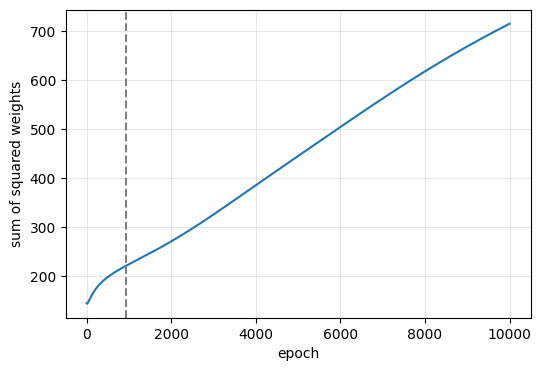

In [3]:
base = fit(64, 10000)
tr, va, a, b, wn, P = base
for e in [0, 916, 10000]:
    print(f"รอบ {e:5d}  ชุดฝึก {tr[e]:.3f}  ชุดตรวจ {va[e]:.3f}  น้ำหนัก² {wn[e]:.1f}")

plt.figure(figsize=(6,4))
plt.plot(wn); plt.axvline(916, ls="--", c="gray")
plt.xlabel("epoch"); plt.ylabel("sum of squared weights"); plt.grid(alpha=0.3)
plt.show()

In [4]:
for l2 in [0.0, 0.001, 0.003, 0.03]:
    report(f"ค่าปรับน้ำหนัก {l2}", fit(64, 10000, l2=l2))

ค่าปรับน้ำหนัก 0.0                 ฝึก 0.019  ตรวจ 0.324  แม่นยำ 1.00/0.91  น้ำหนัก²   714.3
ค่าปรับน้ำหนัก 0.001               ฝึก 0.109  ตรวจ 0.135  แม่นยำ 0.98/0.94  น้ำหนัก²   134.1
ค่าปรับน้ำหนัก 0.003               ฝึก 0.147  ตรวจ 0.153  แม่นยำ 0.98/0.95  น้ำหนัก²    82.3
ค่าปรับน้ำหนัก 0.03                ฝึก 0.580  ตรวจ 0.593  แม่นยำ 0.83/0.78  น้ำหนัก²     7.0


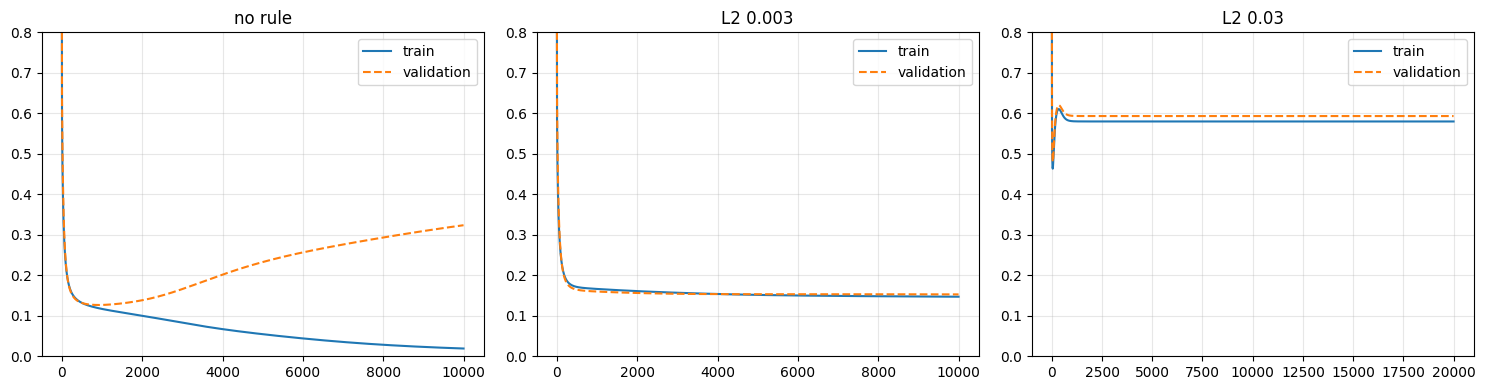

In [5]:
runs = {"no rule": fit(64, 10000), "L2 0.003": fit(64, 10000, l2=0.003), "L2 0.03": fit(64, 20000, l2=0.03)}
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, (t, v, a, b, wn, P)) in zip(axes, runs.items()):
    ax.plot(t, label="train"); ax.plot(v, "--", label="validation")
    ax.set_title(name); ax.set_ylim(0, 0.8); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [6]:
r = fit(64, 10000, l1=0.003); report("L1 0.003", r)
P = r[5]
small = int((np.abs(P["W1"]) < 0.01).sum() + (np.abs(P["W2"]) < 0.01).sum())
alive = np.where(np.abs(P["W2"].ravel()) >= 0.01)[0]
print(f"น้ำหนักที่เล็กกว่า 0.01 มี {small} จาก 192 ตัว   เซลล์ที่ยังทำงาน {[int(i) for i in alive]}")

L1 0.003                           ฝึก 0.116  ตรวจ 0.186  แม่นยำ 0.97/0.93  น้ำหนัก²   126.7
น้ำหนักที่เล็กกว่า 0.01 มี 177 จาก 192 ตัว   เซลล์ที่ยังทำงาน [10, 18, 21, 31, 36, 48, 50, 62]


In [7]:
report("dropout 0.2", fit(64, 10000, drop=0.2))
report("dropout 0.2 + ค่าปรับน้ำหนัก 0.001", fit(64, 10000, drop=0.2, l2=0.001))

dropout 0.2                        ฝึก 0.070  ตรวจ 0.158  แม่นยำ 0.98/0.93  น้ำหนัก²  1847.0
dropout 0.2 + ค่าปรับน้ำหนัก 0.001 ฝึก 0.106  ตรวจ 0.136  แม่นยำ 0.98/0.94  น้ำหนัก²   381.2


In [8]:
def predict(P, X, train_mode=False, p=0.5, rng=None):
    h = np.tanh(X@P["W1"] + P["b1"])
    if train_mode:
        h = h * (rng.random(h.shape) > p) / (1 - p)
    return sig(h@P["W2"] + P["b2"])

In [9]:
tr, va, a, b, wn, P = fit(64, 3000, drop=0.5)
print(f"ปิด dropout ตอนตรวจ   แม่นยำ {accuracy(predict(P, Xva), yva):.3f}")
for k in range(5):
    o = predict(P, Xva, train_mode=True, rng=np.random.default_rng(k))
    print(f"ลืมปิด ครั้งที่ {k+1}     แม่นยำ {accuracy(o, yva):.3f}")

ปิด dropout ตอนตรวจ   แม่นยำ 0.946
ลืมปิด ครั้งที่ 1     แม่นยำ 0.874
ลืมปิด ครั้งที่ 2     แม่นยำ 0.868
ลืมปิด ครั้งที่ 3     แม่นยำ 0.885
ลืมปิด ครั้งที่ 4     แม่นยำ 0.876
ลืมปิด ครั้งที่ 5     แม่นยำ 0.885


In [10]:
report("หมุนทุกรอบ", fit(64, 20000, aug="rotate"))
report("เขย่าทุกรอบ", fit(64, 20000, aug="jitter"))

หมุนทุกรอบ                         ฝึก 0.145  ตรวจ 0.096  แม่นยำ 0.95/0.97  น้ำหนัก²   282.7
เขย่าทุกรอบ                        ฝึก 0.053  ตรวจ 0.159  แม่นยำ 0.98/0.94  น้ำหนัก²   588.3


In [11]:
Xtr, ytr = make_circles(n_samples=600, noise=0.18, factor=0.35, random_state=2)
ytr = ytr.reshape(-1,1).astype(float)
report("ข้อมูลจริง 600 จุด", fit(64, 10000))

Xtr, ytr = make_circles(n_samples=60, noise=0.18, factor=0.35, random_state=2)   # สลับกลับ
ytr = ytr.reshape(-1,1).astype(float)

ข้อมูลจริง 600 จุด                 ฝึก 0.065  ตรวจ 0.100  แม่นยำ 0.97/0.97  น้ำหนัก²   346.5


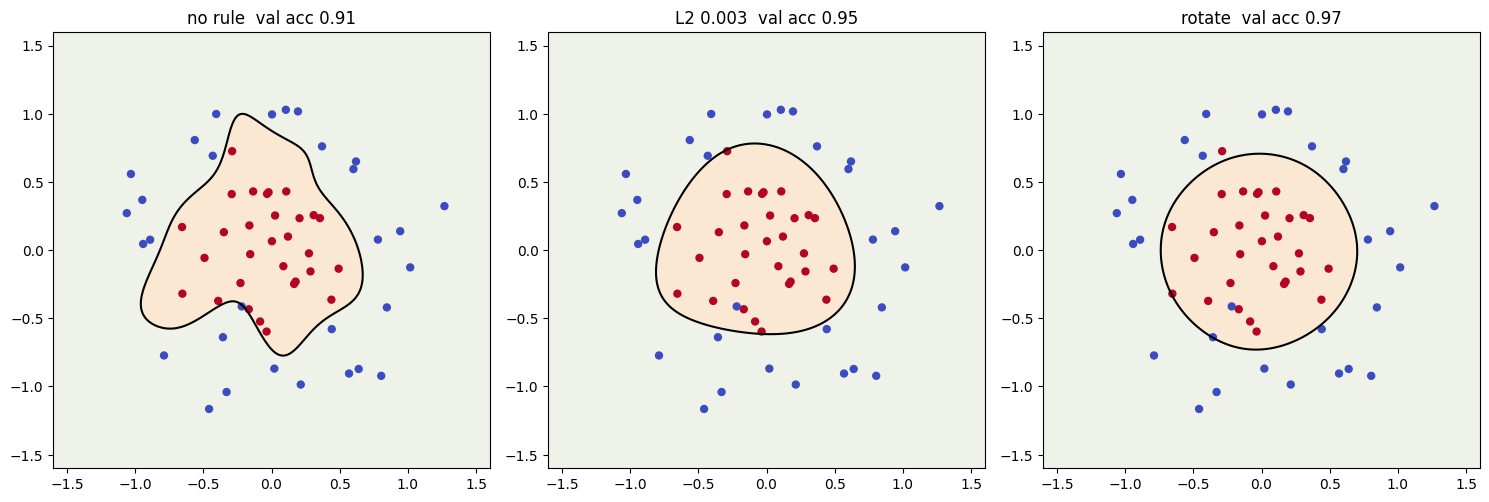

In [12]:
runs = {"no rule": fit(64, 10000), "L2 0.003": fit(64, 10000, l2=0.003), "rotate": fit(64, 20000, aug="rotate")}
g = np.linspace(-1.6, 1.6, 200)
XX, YY = np.meshgrid(g, g)
grid = np.c_[XX.ravel(), YY.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, (tr, va, a, b, wn, P)) in zip(axes, runs.items()):
    o = sig(np.tanh(grid@P["W1"] + P["b1"])@P["W2"] + P["b2"]).reshape(XX.shape)
    ax.contourf(XX, YY, o, levels=[0, 0.5, 1], colors=["#eef2e8", "#fbe8d3"])
    ax.contour(XX, YY, o, levels=[0.5], colors="k")
    ax.scatter(Xtr[:,0], Xtr[:,1], c=ytr.ravel(), cmap="coolwarm", s=25)
    ax.set_title(f"{name}  val acc {b:.2f}"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

In [13]:
def fit_deep(depth, epochs, lr=0.3, seed=0, bn=False, width=16):
    rng = np.random.default_rng(seed)
    sizes = [2] + [width]*depth + [1]
    W = [rng.normal(0, 1, (a, b))/np.sqrt(a) for a, b in zip(sizes[:-1], sizes[1:])]
    b = [np.zeros((1, s)) for s in sizes[1:]]
    gam = [np.ones((1, width)) for _ in range(depth)]     # ปุ่มยืดของ BN
    bet = [np.zeros((1, width)) for _ in range(depth)]    # ปุ่มเลื่อนของ BN
    rmu = [np.zeros((1, width)) for _ in range(depth)]    # ค่าเฉลี่ยสะสม ใช้ตอนสอบ
    rvar = [np.ones((1, width)) for _ in range(depth)]

    def forward(X, train):
        h = X; cache = []
        for i in range(depth):
            z = h@W[i] + b[i]
            if bn:
                if train:                                  # โหมดซ้อม ใช้ค่าเฉลี่ยของชุดนี้
                    mu = z.mean(0, keepdims=True); var = z.var(0, keepdims=True)
                    rmu[i] = 0.9*rmu[i] + 0.1*mu; rvar[i] = 0.9*rvar[i] + 0.1*var
                else:                                      # โหมดสอบ ใช้ค่าเฉลี่ยสะสม
                    mu, var = rmu[i], rvar[i]
                zh = (z - mu)/np.sqrt(var + 1e-5)
                z = gam[i]*zh + bet[i]
            else:
                zh, var = None, None
            hn = sig(z); cache.append((h, zh, var, hn)); h = hn
        return sig(h@W[-1] + b[-1]), cache

    tr = []; va = []; g_first = None
    for e in range(epochs+1):
        o, cache = forward(Xtr, True)
        tr.append(bce(o, ytr)); va.append(bce(forward(Xva, False)[0], yva))
        if e == epochs: break
        d = (o - ytr)/len(ytr)
        gW = [None]*len(W); gb = [None]*len(W)
        gW[-1] = cache[-1][3].T@d; gb[-1] = d.sum(0, keepdims=True)
        dh = d@W[-1].T
        for i in reversed(range(depth)):
            hin, zh, var, hn = cache[i]
            dz = dh*hn*(1 - hn)                            # ย้อนผ่านซิกมอยด์
            if bn:                                         # ย้อนผ่าน batch norm
                gam_g = (dz*zh).sum(0, keepdims=True); bet_g = dz.sum(0, keepdims=True)
                dzh = dz*gam[i]
                dz = (dzh - dzh.mean(0, keepdims=True) - zh*(dzh*zh).mean(0, keepdims=True))/np.sqrt(var + 1e-5)
                gam[i] -= lr*gam_g; bet[i] -= lr*bet_g
            gW[i] = hin.T@dz; gb[i] = dz.sum(0, keepdims=True)
            dh = dz@W[i].T
        if e == 0: g_first = float(np.abs(gW[0]).mean())   # ใบตำหนิที่ชั้นแรกได้รับ
        for i in range(len(W)):
            W[i] -= lr*gW[i]; b[i] -= lr*gb[i]
    o = forward(Xtr, True)[0]; ov = forward(Xva, False)[0]
    return np.array(tr), np.array(va), accuracy(o, ytr), accuracy(ov, yva), g_first

for bn in [False, True]:
    tr, va, a, b, g = fit_deep(6, 3000, bn=bn)
    print(f"ลึก 6 ชั้น batch norm={str(bn):5s}  ฝึก {tr[-1]:.3f}  ตรวจ {va[-1]:.3f}  แม่นยำ {a:.2f}/{b:.2f}  ใบตำหนิชั้นแรก {g:.1e}")

ลึก 6 ชั้น batch norm=False  ฝึก 0.693  ตรวจ 0.693  แม่นยำ 0.47/0.50  ใบตำหนิชั้นแรก 5.3e-07
ลึก 6 ชั้น batch norm=True   ฝึก 0.001  ตรวจ 0.461  แม่นยำ 1.00/0.91  ใบตำหนิชั้นแรก 1.9e-02
